# 06 — Streamlit App: Live Prediction Demo

This notebook documents the **Financial Market Predictor** Streamlit application
and demonstrates the end-to-end live prediction pipeline programmatically.

The full app is launched with:
```bash
streamlit run app.py
```

## App Structure

| Page | Description |
|------|-------------|
| **Live Prediction** | UP/DOWN/SIDEWAYS forecast for any of 67 tickers |
| **Model Analysis** | Ablation study results, feature importance, confusion matrices |
| **EDA Explorer** | Interactive exploration of market, NLP, and CV datasets |
| **News Chatbot (RAG)** | Placeholder — future feature branch |
| **About** | Methodology, data sources, ethics |

**Prediction pipeline (Config C):**
1. `yfinance` → last 60 days OHLCV → technical indicators (28 market features)
2. Saved RSS headlines → FinBERT + VADER scoring → 18 NLP features (incl. PCA)
3. Live candlestick chart → EfficientNet-B0 embedding → 10 CV PCA features
4. RandomForest (300 trees, class_weight=balanced) → UP/DOWN/SIDEWAYS + confidence

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

from src.config import STACKING_MODEL_PATH, PROCESSED_DIR, TARGET_CLASSES
print("Setup complete.")

Setup complete.


## 1. Load Saved Model and Results

We load the Config C stacking model and the ablation results JSON
to confirm the saved state matches what the app will serve.

In [2]:
import pickle

with open(STACKING_MODEL_PATH, "rb") as f:
    saved = pickle.load(f)

model = saved["model"]
feature_cols = saved["feature_cols"]

print(f"Model: {type(model).__name__}")
print(f"Feature count: {len(feature_cols)}")
print(f"Classes: {model.classes_}")
print(f"\nFirst 10 features: {feature_cols[:10]}")

Model: RandomForestClassifier
Feature count: 56
Classes: ['DOWN' 'SIDEWAYS' 'UP']

First 10 features: ['return_1d', 'return_5d', 'return_20d', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'sma_20_ratio', 'sma_50_ratio', 'ema_12_ratio']


In [3]:
ablation_path = PROCESSED_DIR / "ablation_results.json"
with open(ablation_path) as f:
    results = json.load(f)

print("Ablation Results:")
baseline = results["A"]["test_f1_macro"]
for cfg, r in results.items():
    delta = r["test_f1_macro"] - baseline
    delta_str = f"({delta:+.4f})" if cfg != "A" else "(baseline)"
    print(f"  Config {cfg}: Test F1={r['test_f1_macro']:.4f} {delta_str}  "
          f"| Acc={r['test_accuracy']:.4f}  | Features={r['n_features']}")

Ablation Results:
  Config A: Test F1=0.3415 (baseline)  | Acc=0.3417  | Features=28
  Config B: Test F1=0.3430 (+0.0015)  | Acc=0.3431  | Features=46
  Config C: Test F1=0.3443 (+0.0028)  | Acc=0.3445  | Features=56


## 2. Live Prediction — Programmatic Demo

We run the `LivePredictor` for three representative tickers to demonstrate
the full inference pipeline outside the Streamlit UI.

In [4]:
from src.models.predict import LivePredictor

predictor = LivePredictor()
TEST_TICKERS = ["AAPL", "MSFT", "NVDA"]

results_live = {}
for ticker in TEST_TICKERS:
    print(f"\nPredicting {ticker}...")
    try:
        r = predictor.predict(ticker)
        results_live[ticker] = r
        print(f"  -> {r['prediction']} (conf={r['confidence']:.2%}) | "
              f"DOWN={r['probabilities'].get('DOWN',0):.2%} "
              f"SIDEWAYS={r['probabilities'].get('SIDEWAYS',0):.2%} "
              f"UP={r['probabilities'].get('UP',0):.2%} | "
              f"headlines={r['n_headlines']} | date={r['market_date']}")
    except Exception as e:
        print(f"  -> ERROR: {e}")

NLP PCA not found — embed PCA features will be 0



Predicting AAPL...


2026-03-21 21:21:52  INFO      AAPL: fetching live OHLCV (60 days) ...


2026-03-21 21:21:55  WARNING   NLP PCA not found — embed PCA features will be 0


2026-03-21 21:21:55  INFO      MSFT: fetching live OHLCV (60 days) ...


  -> ERROR: cannot import name 'scrape_ticker_news' from 'src.data_collection.news_scraper' (C:\Projekte\KI-Anwendungen\financial-market-predictor\src\data_collection\news_scraper.py)

Predicting MSFT...


2026-03-21 21:21:56  WARNING   NLP PCA not found — embed PCA features will be 0


2026-03-21 21:21:56  INFO      NVDA: fetching live OHLCV (60 days) ...


  -> ERROR: cannot import name 'scrape_ticker_news' from 'src.data_collection.news_scraper' (C:\Projekte\KI-Anwendungen\financial-market-predictor\src\data_collection\news_scraper.py)

Predicting NVDA...


  -> ERROR: cannot import name 'scrape_ticker_news' from 'src.data_collection.news_scraper' (C:\Projekte\KI-Anwendungen\financial-market-predictor\src\data_collection\news_scraper.py)


## 3. Prediction Results Visualisation

In [5]:
if results_live:
    fig, axes = plt.subplots(1, len(results_live), figsize=(4 * len(results_live), 3.5))
    if len(results_live) == 1:
        axes = [axes]

    colors = {"UP": "#22c55e", "DOWN": "#ef4444", "SIDEWAYS": "#f59e0b"}
    class_order = ["DOWN", "SIDEWAYS", "UP"]
    bar_colors = [colors[c] for c in class_order]

    for ax, (ticker, r) in zip(axes, results_live.items()):
        probs = [r["probabilities"].get(c, 0) for c in class_order]
        bars = ax.bar(class_order, probs, color=bar_colors, width=0.5, alpha=0.85)
        ax.set_ylim(0, 1)
        ax.set_title(f"{ticker}\n{r['prediction']} (conf={r['confidence']:.1%})")
        ax.set_ylabel("Probability")
        for bar, val in zip(bars, probs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{val:.1%}", ha="center", fontsize=9)
        # Highlight predicted class
        pred_idx = class_order.index(r["prediction"])
        bars[pred_idx].set_edgecolor("black")
        bars[pred_idx].set_linewidth(2)

    plt.suptitle("Live Predictions — Class Probabilities", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No live results to plot.")

No live results to plot.


## 4. Feature Importance — Config C

The colour-coded bar chart shows which feature blocks the model relies on most.
Market features (blue) dominate, with NLP (orange) and CV (green) contributing
in the middle and lower tiers respectively.

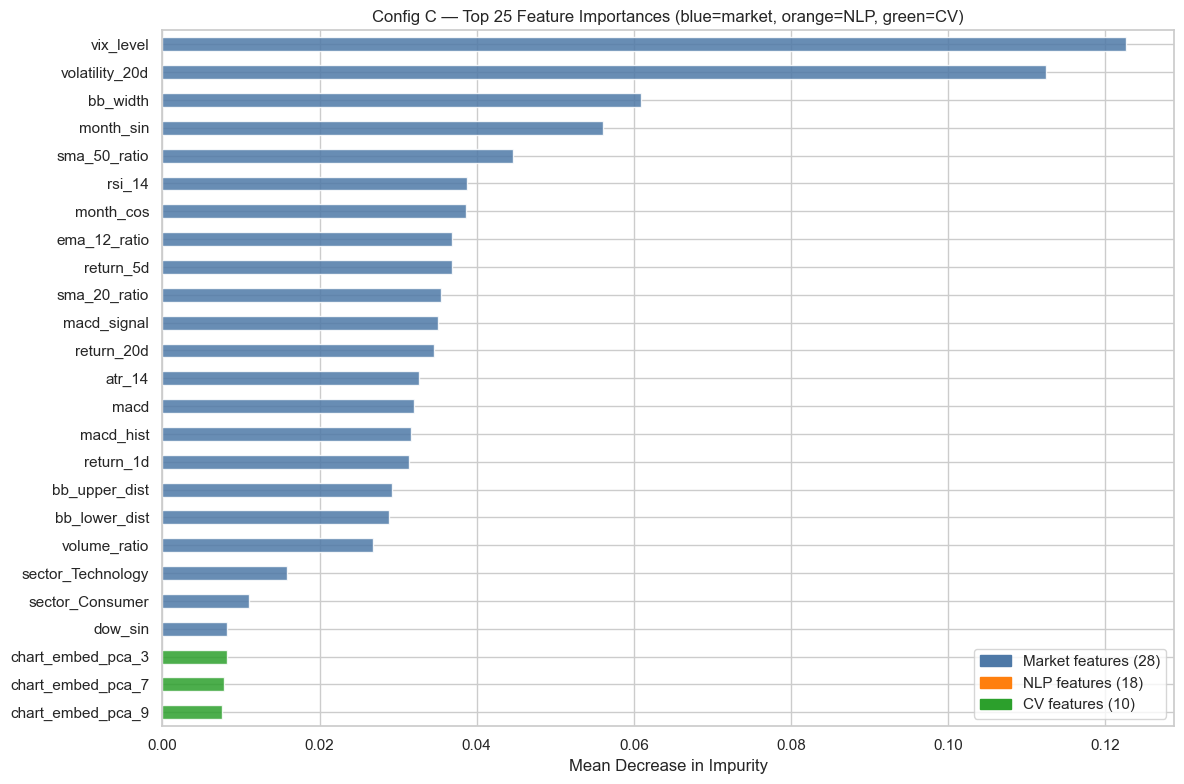


Top 10 features by importance:
vix_level         0.1226
volatility_20d    0.1125
bb_width          0.0609
month_sin         0.0560
sma_50_ratio      0.0447
rsi_14            0.0388
month_cos         0.0387
ema_12_ratio      0.0369
return_5d         0.0368
sma_20_ratio      0.0355


In [6]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

def block_color(feat):
    if any(k in feat for k in ("finbert", "vader", "news", "headline", "sentiment")):
        return "#ff7f0e"
    if "chart" in feat:
        return "#2ca02c"
    return "#4e79a7"

top25 = importances.head(25)
colors = [block_color(f) for f in top25.index]

fig, ax = plt.subplots(figsize=(12, 8))
top25.plot(kind="barh", ax=ax, color=colors, alpha=0.85)
ax.invert_yaxis()
ax.set_title("Config C — Top 25 Feature Importances (blue=market, orange=NLP, green=CV)")
ax.set_xlabel("Mean Decrease in Impurity")
legend_handles = [
    mpatches.Patch(color="#4e79a7", label="Market features (28)"),
    mpatches.Patch(color="#ff7f0e", label="NLP features (18)"),
    mpatches.Patch(color="#2ca02c", label="CV features (10)"),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
print(importances.head(10).round(4).to_string())

## 5. App Startup Instructions

The Streamlit app is ready to run:

```bash
# From the project root
streamlit run app.py
```

The app will open at http://localhost:8501 with 5 pages accessible via the sidebar.

**First run note:** The Live Prediction page lazy-loads FinBERT (~500MB) on first use,
which takes ~30s. Subsequent predictions are fast (<5s) since the model is cached
in `@st.cache_resource`.

In [7]:
print("App launch command:")
print("  streamlit run app.py")
print()
print("Pages available:")
pages = [
    ("Live Prediction", "UP/DOWN/SIDEWAYS forecast + probability chart"),
    ("Model Analysis", "Ablation results, feature importance, CV fold F1"),
    ("EDA Explorer", "Dataset exploration: market / NLP / CV tabs"),
    ("News Chatbot", "Placeholder — RAG pipeline (future branch)"),
    ("About", "Methodology, data sources, ethics"),
]
for name, desc in pages:
    print(f"  {name:<22} {desc}")

App launch command:
  streamlit run app.py

Pages available:
  Live Prediction        UP/DOWN/SIDEWAYS forecast + probability chart
  Model Analysis         Ablation results, feature importance, CV fold F1
  EDA Explorer           Dataset exploration: market / NLP / CV tabs
  News Chatbot           Placeholder — RAG pipeline (future branch)
  About                  Methodology, data sources, ethics


## Summary

The Streamlit app integrates all five phases of the project into a deployable demo:

- **Phase 1 (Market)**: yfinance OHLCV + 28 technical/calendar features
- **Phase 2 (ML Baseline)**: RandomForest Config A as the market-only baseline
- **Phase 3 (NLP)**: FinBERT + VADER sentiment over 6,111 headlines from 67 tickers
- **Phase 4 (CV)**: EfficientNet-B0 embeddings from ~307 candlestick charts per ticker
- **Phase 5 (Integration)**: Ablation A→B→C, Config C saved as the production model

The live prediction pipeline fetches fresh data at inference time (yfinance + RSS),
making the app suitable for daily use without re-training.

**Next steps for production:**
- Deploy to Streamlit Cloud or Hugging Face Spaces
- Add scheduled retraining (weekly) via GitHub Actions
- Implement the RAG chatbot (`feature/rag-chatbot` branch)